# Lab 1: First Contact with Sentinel-1 over Kraków

This notebook is designed to do four things:

1. initialize the Earth Engine environment,
2. load Sentinel-1 GRD data over Kraków,
3. compare how SAR brightness changes across time,
4. some introductory .

Students should become comfortable with:

- loading satellite data in Python,
- working with an `ee.ImageCollection`,
- computing simple summary products,
- plotting histograms,
- comparing maps through time.

By the end of this notebook, students should be able to:

- explain what a Sentinel-1 image collection is,
- filter the collection to a consistent subset of scenes,
- produce a median monthly image for a given year,
- compare brightness distributions between years,
- compute a simple change metric,
- describe what they think the observed differences might represent.

---

In [1]:
!uv add ee geemap pandas matplotlib IPython

Resolved 184 packages in 4.47s                                       
Prepared 30 packages in 26.66s                                           ⠋ Preparing packages... (0/0)                                                   
░░░░░░░░░░░░░░░░░░░░ [0/38] Installing wheels...                                warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 38 packages in 1m 48s                             
 + anywidget==0.10.0
 + blessings==1.7
 + bqplot==0.12.30
 + cryptography==46.0.7
 + earthengine-api==1.7.22
 + ee==0.2
 + eerepr==0.1.2
 + future==1.0.0
 + geemap==0.37.2
 + geocoder==1.38.1
 + google-api-core==2.30.3
 + google-api-python-client==2.194.0
 + google-auth==2.49.2
 + google-auth-httplib2==0.3.1

In [46]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import datetime

print("Imports loaded.")

Imports loaded.


## 1. Initialize Google Earth Engine

This notebook assumes the Earth Engine Python API is already installed and authenticated.

If you are running this for the first time on a new machine, you may need to run:

```python
ee.Authenticate()
```

and then initialize with the project ID.

In [47]:
!earthengine authenticate --force

^C


In [48]:
ee.Initialize(project="fast-synapse-453516-j0") # it's a generated name, I wonder if these are randomly selected ;D 
print("Earth Engine initialized OK.")

Earth Engine initialized OK.


## 2. Define the area of interest and some reusable settings

We use a small rectangle around Kraków.

We will work with **Sentinel-1 GRD** scenes that satisfy a consistent set of filters:

- intersect the AOI,
- same month or date range,
- IW mode,
- both VV and VH available,
- ascending orbit,
- 10 m resolution.

Using consistent filtering is important because it reduces differences caused by acquisition geometry rather than real surface change.

**Question (4 pts): Throughout this lab, we will be comparing SAR GRD level data to compare the same AOI over different periods of time. Why is it important to keep the orbit direction consistent when comparing scenes over time?**

**ANSWER:**
As learnt during 2nd lab layover and shadowing are important factors to consider for SAR imagery, as such it's imperative that the orbit direction stays the same - the angle that the waves are emitted at stays the same. Thanks to this consistency there should be no differences caused by mismatch in shadowing, layover etc.

In [49]:
# Area of interest: Kraków and surrounding urban/peri-urban area
aoi = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])

# Analysis settings
ORBIT_PASS = "ASCENDING"
MODE = "IW"
RESOLUTION = 10

# Year range used later in the notebook
years = list(range(2015, 2025))

m = geemap.Map()
m.centerObject(aoi, 10)
m.addLayer(aoi, {"color": "red"}, "AOI")
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

https://developers.google.com/earth-engine/apidocs/ee-imagecollection-filterdate <- docs for the methods

## 3. Helper functions

These functions do most of the repetitive work:

- `get_s1_collection(...)`: build a filtered Sentinel-1 collection,
- `get_monthly_median(...)`: produce a median image for a given month and year,
- `show_scene_metadata(...)`: inspect dates and metadata,
- `fixed_histogram(...)`: compute a histogram for plotting,
- `region_stats(...)`: compute simple summary statistics over the AOI.

In [50]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass=ORBIT_PASS,
                      mode=MODE,
                      resolution=RESOLUTION):
    """
    Return a filtered Sentinel-1 GRD ImageCollection.
    """
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        # filtering the collection in regard to the parameters
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('orbitProperties_pass', orbit_pass))
        .filter(ee.Filter.eq('resolution_meters', resolution))
    )
    # print(collection.__dict__)
    
    return collection



def get_monthly_median(year, month=8, region=aoi):
    """
    Return the median Sentinel-1 image for a given month and year.
    By default, this is August because it reduces seasonal variation
    and avoids snow-related complications.
    """
    start = f"{year}-{month:02d}-01"
    if month == 12:
        end = f"{year + 1}-01-01"
    else:
        end = f"{year}-{month + 1:02d}-01"

    #YOUR CODE HERE (10 pts). IN SECTION 4, YOU MANUALLY GOT THE COLLECTION AND SET THE MEDIAN.
    #SINCE WE INTEND TO DO THIS MULTIPLE TIMES, LETS PUT THIS IN A FUNCTION
    collection = get_s1_collection(start, end, region)
    
    # Calculate the median composite
    image = collection.median()
    # https://developers.google.com/earth-engine/apidocs/ee-imagecollection-median

    return image.set({
        "year": year,
        "month": month,
        "scene_count": collection.size()
    })


def show_scene_metadata(collection, basic = True):
    """
    Print selected metadata for scenes in a collection.
    Useful for discussing repeat intervals and duplicate dates.
    """
    times = collection.aggregate_array("system:time_start").getInfo()
    passes = collection.aggregate_array("orbitProperties_pass").getInfo()
    platforms = collection.aggregate_array("platform_number").getInfo()
    relative_orbits = collection.aggregate_array("relativeOrbitNumber_start").getInfo()
    slice_numbers = collection.aggregate_array("sliceNumber").getInfo()
    total_slices = collection.aggregate_array("totalSlices").getInfo()
    instrument_modes = collection.aggregate_array("instrumentMode").getInfo()
    polarisations = collection.aggregate_array("transmitterReceiverPolarisation").getInfo()
    resolutions = collection.aggregate_array("resolution_meters").getInfo()
    orbit_numbers = collection.aggregate_array("orbitNumber_start").getInfo()

    for t, p, sat, rel_orb, slice_num, tot_slice, mode, pol, res, orb_num in zip(
        times, passes, platforms, relative_orbits, slice_numbers, 
        total_slices, instrument_modes, polarisations, resolutions, orbit_numbers
    ):
        dt = datetime.datetime.utcfromtimestamp(t / 1000)
        info_message = f"{dt.date()} | {p} | S1{sat} "
        if not basic:
            info_message += f"| RelOrb:{rel_orb} | " \
                f"Slice:{slice_num}/{tot_slice} | {mode} | {pol} | " \
                f"{res}m | Orb:{orb_num}"

        print(info_message)


def fixed_histogram(image, region, band, hist_min, hist_max, n_bins=100, scale=10):
    """
    Compute a fixed histogram for one band of an Earth Engine image.
    Returns bin centers, counts, and bin width.
    """
    hist = image.select(band).reduceRegion(
        reducer=ee.Reducer.fixedHistogram(hist_min, hist_max, n_bins),
        geometry=region,
        scale=scale,
        maxPixels=1e9,
        bestEffort=True
    ).get(band)

    hist = ee.List(hist).getInfo()
    bin_edges = [row[0] for row in hist]
    counts = [row[1] for row in hist]
    bin_width = (hist_max - hist_min) / n_bins
    bin_centers = [edge + bin_width / 2 for edge in bin_edges]

    return bin_centers, counts, bin_width


def normalize_counts(counts):
    total = sum(counts)
    if total == 0:
        return counts
    return [c / total for c in counts]


def region_stats(image, region, band):
    """
    Return mean, median, std dev, and max for a selected band.
    """
    stats = image.select(band).reduceRegion(
        reducer=(
            ee.Reducer.mean()
            .combine(ee.Reducer.median(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True)
            .combine(ee.Reducer.max(), sharedInputs=True)
        ),
        geometry=region,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    return {
        "mean": stats.get(f"{band}_mean"),
        "median": stats.get(f"{band}_median"),
        "stdDev": stats.get(f"{band}_stdDev"),
        "max": stats.get(f"{band}_max"),
    }

print("Helper functions defined.")

Helper functions defined.


## 4. Inspect one month of data in detail

This section focuses on January 2024.  
The goal is no deep interpretation yet — it is simply to inspect the collection and compare the returned GRD file, comparing the scene with your a priori knowledge of the Krakow area.

We want to return a filtered Sentinel-11 GRD ImageCollection that is filtered by:
- region
- start_date and end_date
- instrumentMode = "IW"
- transmitterReceiverPolarisation contains both "VV" and "VH"
- orbitProperties_pass = "ASCENDING"
- resolution_meters = 10

Things you might notice:
- For a given AOI, multiple slices can exist,
- one overpass can be represented by multiple scene slices,
- image collections often contain more than one product per date over the AOI.



In [51]:
# Visualization presets
vv_vis = {"min": -20, "max": 0}
vh_vis = {"min": -28, "max": -5}
#YOU WILL NEED TO WRITE THE get_s1_collection FUNCTION TO GET THIS TO WORK. ONCE YOU HAVE
#THE FUNCTION WORKING, PLACE IT IN THE FUNCTIONS CODE BLOCK IN SECTION 3.
jan_2024 = get_s1_collection("2024-01-01", "2024-02-01", region=aoi)

#YOU WILL NEED TO ADAPT THE show_scene_metadata() FUNCTION TO ANSWER THE QUESTION BELOW
print("Image count:", jan_2024.size().getInfo())
show_scene_metadata(jan_2024, False)

jan_2024_img = jan_2024.median().clip(aoi)

m = geemap.Map()
m.centerObject(aoi, 10)

#If we were plotting just one img, you would simply use the line below. A split_map allows
#two scenes to be compared via a slider bar.
#m.addLayer(jan_2024_img.select("VV"), vv_vis, "VV January 2024")

m.split_map(
    left_layer=geemap.ee_tile_layer(jan_2024_img.select("VV"), vv_vis, "VV January 2024"),
    right_layer=geemap.ee_tile_layer(jan_2024_img.select("VH"), vh_vis, "VH January 2024")
)
display(m)

Image count: 10
2024-01-05 | ASCENDING | S1A | RelOrb:102 | Slice:13/29 | IW | ['VV', 'VH'] | 10m | Orb:51974
2024-01-05 | ASCENDING | S1A | RelOrb:102 | Slice:14/29 | IW | ['VV', 'VH'] | 10m | Orb:51974
2024-01-10 | ASCENDING | S1A | RelOrb:175 | Slice:13/29 | IW | ['VV', 'VH'] | 10m | Orb:52047
2024-01-10 | ASCENDING | S1A | RelOrb:175 | Slice:14/29 | IW | ['VV', 'VH'] | 10m | Orb:52047
2024-01-17 | ASCENDING | S1A | RelOrb:102 | Slice:13/29 | IW | ['VV', 'VH'] | 10m | Orb:52149
2024-01-17 | ASCENDING | S1A | RelOrb:102 | Slice:14/29 | IW | ['VV', 'VH'] | 10m | Orb:52149
2024-01-22 | ASCENDING | S1A | RelOrb:175 | Slice:13/29 | IW | ['VV', 'VH'] | 10m | Orb:52222
2024-01-22 | ASCENDING | S1A | RelOrb:175 | Slice:14/29 | IW | ['VV', 'VH'] | 10m | Orb:52222
2024-01-29 | ASCENDING | S1A | RelOrb:102 | Slice:13/29 | IW | ['VV', 'VH'] | 10m | Orb:52324
2024-01-29 | ASCENDING | S1A | RelOrb:102 | Slice:14/29 | IW | ['VV', 'VH'] | 10m | Orb:52324


Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (4 pts): We know Sentinel-1 has an approximately 6-day repeat time. However, from the metadata presented above, there are 10 images that GEE grabbed, two for each acquisition day. Why is that? Do not guess, look into the metadata for those scenes to get your answer. You will need to modify the metadata function in the helper functions code block above. Please also adjust the print function to print the metadata field you thinks supports your answer**

Some common metadata fields are:`time_start`, `platform_number`, `orbitProperties_pass`, `relativeOrbitNumber_start`, `sliceNumber`, `totalSlices`, `instrumentMode`, `transmitterReceiverPolarisation`, `resolution_meters`, and `orbitNumber_start`. 

> For this purpose I've extended the metadata function, I've added extra parameter to allow backward compability with the original

**ANSWER:** It seems that area over Kraków needs to be captured with two slices per day. As it most probably falls at the border of two slices. It can be clearly be seen for this example:

```
2024-01-29 | ASCENDING | S1A | RelOrb:102 | Slice:13/29 | IW | ['VV', 'VH'] | 10m | Orb:52324
2024-01-29 | ASCENDING | S1A | RelOrb:102 | Slice:14/29 | IW | ['VV', 'VH'] | 10m | Orb:52324
```

Every property is exactly the same apart for slice which are `13/29` and `14/29`, as such each day has 2 images instead of just one

## 5. Compare early and recent August composites

For the first change-oriented comparison, we use one August composite near the beginning and one near the end of the analysis period.

Why August?
- it helps keep the seasonal window consistent,
- it avoids winter snow issues,
- it gives a cleaner year-to-year comparison.

Why not August?
- Vegetative growth may impact radar returns (e.g., depending on the conditions earlier in the summer, foliage may be at a different growth level

> **If you are curious:**  
> Once you have finished the lab, you can change the month from August to January or April (or any of your choice) and describe how the maps, histograms, or time series plots differ. Maybe another month would be a better choice?


In [52]:
# Build one August median image for every year
images_by_year = {year: get_monthly_median(year, month=8, region=aoi) for year in years}

first_year = years[0]
last_year = years[-1]

img_first = images_by_year[first_year]
img_last = images_by_year[last_year]

m = geemap.Map()
m.centerObject(aoi, 11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_first.select("VV"), vv_vis, f"VV {first_year}"),
    right_layer=geemap.ee_tile_layer(img_last.select("VV"), vv_vis, f"VV {last_year}")
)
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (8 pts): Compare the 2015 and 2025 median maps carefully.** 

- Start with the old town. Do you notice much change? Why do you think that is?
- Find an area that has significant change in bright pixels. What does this represent?
- What about the darkest pixels?
- Pixels or groups of pixels that are consistently bright across many years are excellent candidates for 
      the persistent scatterer, which we will cover in a later lab. What features do you think might make 
      excellent candidates for persistent scatterer analysis? 

**ANSWER:**

- **Old town** - firstly there is a change around the old town - most probably park seems to have been replaced with urban structures - this area (in North of the old town) seems to be less urbanized/have larger variety as in there is probably more vegetation, as the area around seems to be less bright. The main square seems to be darker too - it might be because of more vegetation in the square, since it's a median of a month I discard a possibility of events that would use tents etc.
- Areas south and west to campus in 2025 have much more bright pixels - more buildings/housing in the areas, which is consistent with Kraków's expansion trend. Also South and North of Kraków have much brighther pixels - growing suburbs and hubs for companies. It's also a visible trend in Kraków's expansion.
- Water bodies have the darkest pixels - lakes and Vistula river, which is expected. It's worth noting that highway South to the city is also a bit darker than its neighbourhood
- First of all ubran parts are the best candidates - they should be persistent across the years as well as they react similarily for SAR. Another one would maybe be bridges - they seem to be constantly bright as well.


## 6. Histogram comparison of VV brightness

A histogram is a simple way to summarize the distribution of pixel brightness values over the AOI.

Here we compare the VV histograms for the first and last August composites.

This is useful because a map can be visually overwhelming, while a histogram can show whether:
- the distribution shifts,
- the bright tail changes,
- one year has more bright scatterers than another.

>Important note:
A histogram of the whole AOI is a blunt tool. If the signal is subtle, the result may be hard to interpret. That is okay — part of the lesson is learning that some analyses are more sensitive than others.

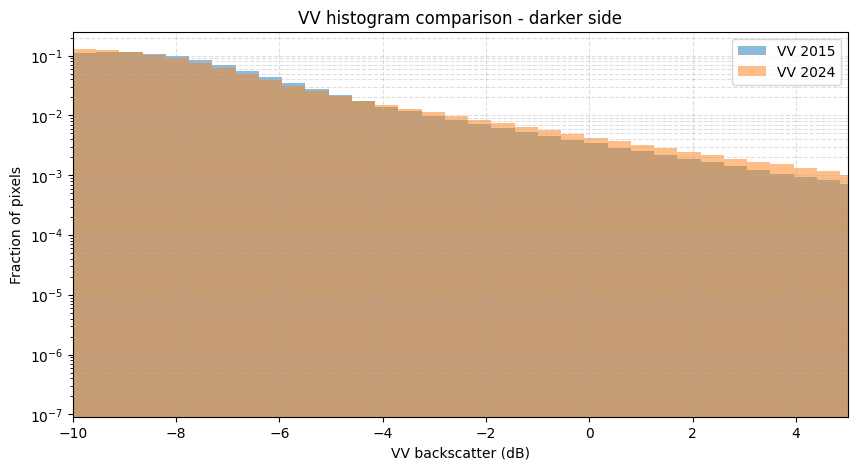

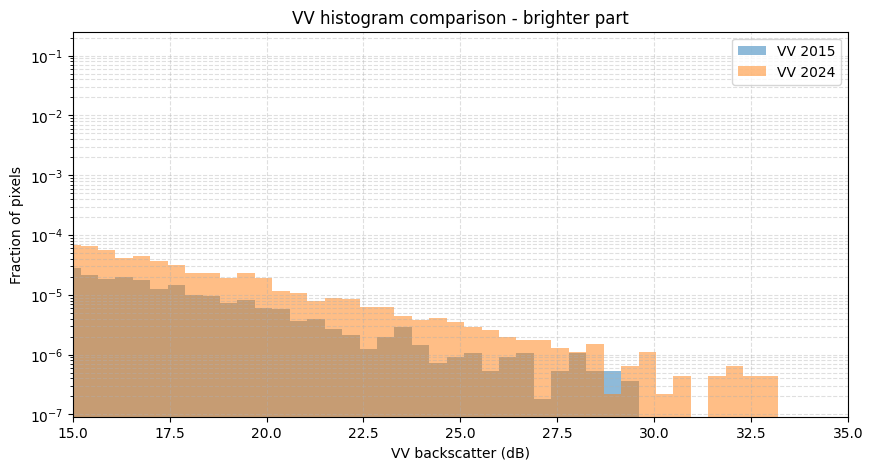

2015 VV stats: {'mean': -8.672231229609428, 'median': -8.875194515916217, 'stdDev': 3.06930373459068, 'max': 29.39563219751134}
2024 VV stats: {'mean': -9.286140736658622, 'median': -9.750873222813965, 'stdDev': 3.426506464939447, 'max': 33.13410592782661}


In [28]:
# Histogram settings
vv_hist_min = -10
vv_hist_max = 35
vv_hist_bins = 100

x1, y1, bw1 = fixed_histogram(img_first, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)
x2, y2, bw2 = fixed_histogram(img_last, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)

y1n = normalize_counts(y1)
y2n = normalize_counts(y2)

plt.figure(figsize=(10, 5))
plt.bar(x1, y1n, width=bw1, alpha=0.5, label=f"VV {first_year}")
plt.bar(x2, y2n, width=bw2, alpha=0.5, label=f"VV {last_year}")
plt.xlabel("VV backscatter (dB)")
plt.ylabel("Fraction of pixels")
plt.title("VV histogram comparison - darker side")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.xlim([-10, 5])
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x1, y1n, width=bw1, alpha=0.5, label=f"VV {first_year}")
plt.bar(x2, y2n, width=bw2, alpha=0.5, label=f"VV {last_year}")
plt.xlabel("VV backscatter (dB)")
plt.ylabel("Fraction of pixels")
plt.title("VV histogram comparison - brighter part")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.xlim([15, 35])
plt.legend()
plt.show()

stats_first = region_stats(img_first, aoi, "VV")
stats_last = region_stats(img_last, aoi, "VV")

print(f"{first_year} VV stats:", stats_first)
print(f"{last_year} VV stats:", stats_last)

**QUESTION (4 pts): What do you notice about the distribution on the bright side tail of the distribution of pixel brightness? Discuss both the number of bright pixels and their distribution, and what each represents. ADJUST THE X-AXIS IN THE CODE TO GRAB THE PART OF THE HISTOGRAM THAT SUPPORTS YOUR ANSWER BELOW**

**ANSWER:** the bright side tail contains much less reflected pixels, which makes sense looking at previous maps - there are less extremally bright objects/parts of AOI compared to darker ones. Interestingly it seems that for 2024 there was overall more bright pixels reflected, which makes sense given the expansion of the city. For lower backscatter values one can see that in 2015 there were either almost as many or more pixels with weak backscatter compared to 2024. Interestingly there are areas with VV backscatter level that was not seen in 2015 - which is further shown on the statistics comparison. There is one "peak" for 2015 values over ones from 2024 - which means that for this backscatter level it has actually decreased over the years. 

It's worth adding that the bright part might be also more underlined/presented for 2024 because of artifacts caused by radar properties, such as star shaped artifact in North East part of the city, water does not really influence the charts as it's backscatter is much smaller than -10dB :)

As it was explained on the lecture the star shaped artifacts are caused by specular reflection - worth noting


## 7. Compute a simple SAR ratio image: VV - VH

A very simple and common calculation is the difference between the VV and VH bands:

\[
VV - VH
\]

This is not a full physical interpretation yet, but it is a useful derived quantity because it often separates surface types better than VV or VH alone. We will cover polarimetric SAR in later labs and lectures,
but the important thing to know here is that VV returns most strongly come from hard surface reflectors, things
like buildings, bridges, and roads, while VH returns most strongly come from distributed or volumetric scattering,
for example by bouncing many times in vegetative growth before returning to the satellite.

Here we compare the ratio-like image `VV - VH` for the first and last August composites.

To do this, select the VV band of the first image, subtract the VH band of the first image, then rename the result "VVVH" Then, do the same for the last image. Then, plot this as a split_map centered on the AOI.


In [44]:
# YOUR CODE HERE (16 pts)
img_first = images_by_year[first_year]
img_last = images_by_year[last_year]

# without it it was all black
diff_vis = {
    'min': 0,
    'max': 15,
}

diff_first = (img_first.select('VV')
              .subtract(img_first.select('VH'))
              .rename('VVVH'))

diff_last = (img_last.select('VV')
             .subtract(img_last.select('VH'))
             .rename('VVVH'))

m = geemap.Map()
m.centerObject(aoi, 11)

m.split_map(
    left_layer=geemap.ee_tile_layer(diff_first, diff_vis, "VV-VH First Year"),
    right_layer=geemap.ee_tile_layer(diff_last, diff_vis, "VV-VH Last Year")
)
m.add_colorbar(diff_vis, label="VV-VH (dB)", layer_name="VV-VH")

display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (4 pts): Where do you notice the biggest changes in the VV-VH ratio. Focus not only on the largest increases, but also the largest decreases. In doing so, are we making a qualitative or quantitative assesment?**

**ANSWER:** There are more smaller differences (darker ones) in the city center and slightly to the North East - the areas have not changed as much. The biggest diffences I can see is in the South of the city - they are much more developed now, which is consistent with previous results. East of Kraków has a lot of dark changes - biggest decreases in my opinion. Another thing I can see are the areas which had big increase (brigth values) before, but now are even brighter or are more complex/wider. 

I believe it's a qualitative assesment as the task is to compare the results/images as a whole, not pixel/element by pixel/element which would be a quantative assesment.


## 8. Visualize change in VV - VH

Now we map the difference:

\[
(VV - VH)_{last} - (VV - VH)_{first}
\]

Positive values indicate an increase in this quantity through time, while negative values indicate a decrease.

At this stage, you should not over-interpret the result. The correct first step is simply to identify:
- where change appears strongest,
- whether it is spatially clustered,
- whether it seems plausible.



In [62]:
# Visualization presets
change_vis = {"min": -3, "max": 3, "palette": ["blue", "white", "red"]}
# I've used my naming convention :)
diff_change = diff_last.subtract(diff_first).rename("dVVVH")

m2 = geemap.Map()
m2.centerObject(aoi, 11)
m2.addLayer(diff_change, change_vis, "Change in VV-VH")
m2.add_colorbar(change_vis, label="VV-VH (dB)", layer_name="VV-VH")
# add highlighted area
aoi_blue = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])
m2.addLayer(aoi_blue, {"color": "red"}, "AOI")

display(m2)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

**QUESTION (4 pts): Investigate this change map carefully.** 

- First, identify an area that had a large scale increase in this ratio. Why did VV increase relative to VH in this area?
- Second, I want you to find the area in the top right of the map that had a significant decrease in VV/VH. You can use the code block below to highlight where it is. Using optical data (google maps is fine here), tell me what that feature is. Why do you think it may have had strong VV in 2015, and strong VH in 2025, even though they were both taken in August?**

`aoi_blue = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])`

`m2.addLayer(aoi, {"color": "red"}, "AOI")`

**ANSWER:** The single biggest increase in ratio can be seen for exit road in the North of Kraków and West of Niepołomice. actually looking at roads some of the larger increases are along main roads. It makes sense as the increase means surfaces are smoother than they used to be which makes sense for large roads and large warehouses.

The area seems to be a large field with crops. The shift might have happened due to crop condition change between the years or maybe the techniques for crop cultivating have changed. Strong VV in 2015 suggests that the fields was more regular or less dense, different type of vegetation. For 2025 the land cover by vegetation was probably denser and more "uniquely" placed in regard to their placement which might cause VV to be less significant in the ratio than VH

In [73]:
m22 = geemap.Map()
m22.centerObject(aoi, 11)
m22.addLayer(diff_change, change_vis, "Change in VV-VH")
m22.add_colorbar(change_vis, label="VV-VH (dB)", layer_name="VV-VH")
# add highlighted area
aoi_blue = ee.Geometry.Rectangle([20.19, 50.11, 20.21, 50.12])
m22.addLayer(aoi_blue, {"color": "red"}, "The biggest decrease")

display(m22)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

## 9. Threshold-based change mask

This section turns a continuous change image into a very simple binary mask.

This is intentionally crude. The point is to show that:
- a threshold is a choice,
- different thresholds produce different maps,
- classification decisions require judgment.

The logic below flags pixels that:
- started relatively low,
- ended relatively high,
- increased by at least a chosen amount.

In [72]:
low_thresh = 15
high_thresh = -5
change_thresh = 3

#WRITE THE LOGIC TO FLAG PIXELS THAT HAVE SATISFIED THE ABOVE THRESHOLDS. USEFUL LOGIC
#FUNCTIONS INCLUDE .And(), .Or(), .lt() for less than, .gt() for greater than
transition = (
    #YOUR CODE HERE (10 pts)
     diff_first.lt(low_thresh)           # First year was low scattering
    .And(diff_last.gt(high_thresh))     # Last year is high scattering
    .And(diff_change.gt(change_thresh)) # Change exceeds threshold
    .rename("transition")
)

#This block will print your fraction of the AOI that you have flagged
frac = transition.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("transition").getInfo()

print("Fraction flagged:", frac)

m3 = geemap.Map()
m3.centerObject(aoi, 11)
# m3.addLayer(img_last.select("VV"), vv_vis, f"VV {last_year}")
m3.addLayer(diff_change, change_vis, "diff between VV and VH")
m3.addLayer(
    transition.updateMask(transition),
    {"min": 0, "max": 1, "palette": ["black"]},
    "Transition mask"
)
display(m3)

Fraction flagged: 0.09143418727529004


Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

**QUESTION (4 pts): Why did you choose the thresholds that you chose? Was it easy, or even possible, to arrive at a classification scheme that you think accurately captured urban development in the Krakow area?**

**ANSWER:** I have selected the thresholds based on my previous results and slight adjustments to the values based on my result assessment. I can see that there are a lot of dark spots/clusters for areas that have drastically developed - which would have a large positive difference change - after showing the difference layer it's visible that the two layers overlap.

It was not easy, but I believe it's possible to set optimal parameters that would render an accurate scheme for capturing urban development across the years. It would require hyperparameters, optional animations and generally this kind of techniques to identify most accurate settings. 


## 10. Histogram of the change image

This plot summarizes the distribution of the `VV - VH` change image.

It is useful for:
- seeing whether most pixels changed very little,
- checking whether the distribution is centered near zero,
- deciding whether the threshold values are reasonable.

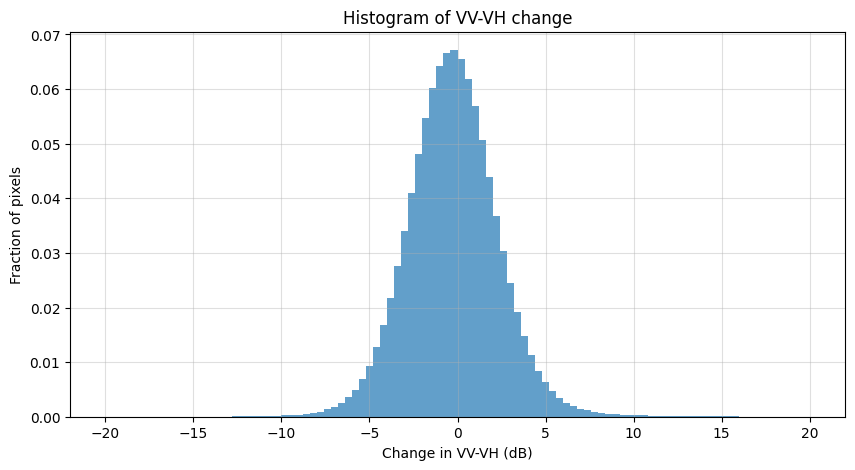

In [45]:
x_change, y_change, bw_change = fixed_histogram(
    diff_change, aoi, "dVVVH", hist_min=-20, hist_max=20, n_bins=100
)

y_change_norm = normalize_counts(y_change)

plt.figure(figsize=(10, 5))
plt.bar(x_change, y_change_norm, width=bw_change, alpha=0.7)
plt.xlabel("Change in VV-VH (dB)")
plt.ylabel("Fraction of pixels")
plt.title("Histogram of VV-VH change")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (4 pts):
First, notice that this histogram is not centered on 0, it is shifted slightly towards negative values. This means that VV is stronger in 2015 than in 2025! Does this go against all the analysis you just did? If this is confusing, go back to the very first split_image, comparing VV in 2015 and 2025. When we first did that, we were focused on the brightest pixels only. Now I want you to focus on the map as a whole, ignoring the brightest pixels. What can you say about the strength of VV returns in 2015 vs 2025. Thinking about what we have learned about scattering physics, what do you think might be the cause of this?**

**ANSWER:** I can see it's not centered to 0, more "drastic" changes are near 10db than -10dB nonetheless the bigger part of values is below 0. I think that it does not deny the previous analysis, as most of the analysis (beside some additional notes on darker parts) was focused on bright spots and parts that were scarse but strong - not the general trend. 

After looking at `VV` comparison for first and last year I can say that while areas that were bright in the first year "expanded" in terms of area next to them being bright as well, the "background" seems to be darker, body of water which I believe is Bagry also has expanded. So generally speaking the bright spots got amplified, however dark ones are darker too. 

My intuition tells me that the general decreasing trend is because of more smooth surfaces that cause specular reflection and less backscatter to the satellite. While for progressing urban areas - they got brighter because signal bounces twice and is stronger.


For simplicity I've copied the code block below

In [74]:
# Build one August median image for every year
images_by_year = {year: get_monthly_median(year, month=8, region=aoi) for year in years}

first_year = years[0]
last_year = years[-1]

img_first = images_by_year[first_year]
img_last = images_by_year[last_year]

m = geemap.Map()
m.centerObject(aoi, 11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_first.select("VV"), vv_vis, f"VV {first_year}"),
    right_layer=geemap.ee_tile_layer(img_last.select("VV"), vv_vis, f"VV {last_year}")
)
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## 11. Track a simple metric through time

Instead of comparing only two years, we can compute the same metric for every year.

Here we calculate the fraction of the AOI with:

\[
VV - VH > threshold
\]

for each August composite.

This is a very simple time-series summary. It is not a full change detection method, but it requires:
- looping over years,
- deriving one metric per image,
- plotting a time series.

,year,frac_flagged
0,2015,0.026686
1,2016,0.017477
2,2017,0.018768
3,2018,0.022492
4,2019,0.025243
5,2020,0.026361
6,2021,0.027477
7,2022,0.038199
8,2023,0.029211
9,2024,0.031171


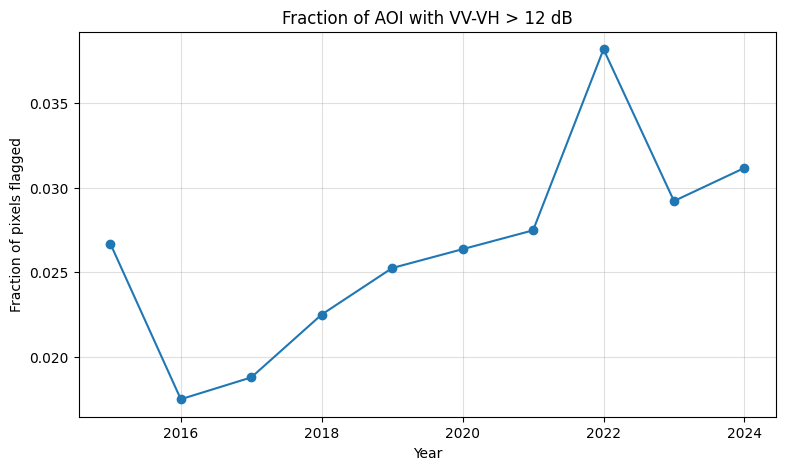

In [76]:
ratio_thresh = 12
rows = []

for year in years:
    yearly = images_by_year[year]
    ratio = yearly.select("VV").subtract(yearly.select("VH")).rename("VVVH")

    frac_flagged = ratio.gt(ratio_thresh).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).get("VVVH").getInfo()

    rows.append({
        "year": year,
        "frac_flagged": frac_flagged
    })

df = pd.DataFrame(rows)
display(df)

plt.figure(figsize=(9, 5))
plt.plot(df["year"], df["frac_flagged"], marker="o")
plt.xlabel("Year")
plt.ylabel("Fraction of pixels flagged")
plt.title(f"Fraction of AOI with VV-VH > {ratio_thresh} dB")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (8 pts):**

- **Why did you choose the threshold that you did?**
- **This is our first attempt to actually quantify and track a specific metric of urban development over a longer time period. Do you think the metric you arrived at accurately quantifies the amount of urban development? Or do you think the metric shows overall trends in urban development, but that there may be too many assumptions to accurately quantify this?**
- **What do you think may be happening with the outliers?**

**ANSWER:**

- I chose 12 dB as it filters out only the strongest differences between `VV` and `VH`, so the yearly analysis is focused on urban areas that are the most interesting (in my opinion) for the case, it can show how the city expands. It's not perfect, but rather an approximation that can pick up the general trend for urban areas. Also 12 dB was not far from the original 15 dB which I started playing with :)
- As I stated in the previous point in my opinion it's not an accurate measure but rather a show of trend in urban development. It can be accurate but it strongly depends on selected threshold and influence of outliers. There are some assumptions that are not precisely "taken into account" as such I'd say it's not accurate, but shows the trend well
- I think because the statistics are aggregated for the entire AOI, outliers might have a small influence on the results, of course the larger the threshold is the more huge outliers will influence the results slightly more - so it's all about balancing the param values. Outliers might come from areas that are not urban, but rather comply with properties of SAR in such a way that they achieve high difference - artifacts that spill over other pixels.


> Note: if the animations are not shown it's because of my latest comment changes in vs code :)